In [1]:
import h5py
import pandas as pd

In [7]:
f = h5py.File('GW170817_GWTC-1.hdf5', 'r')
path = 'GW170817_GWTC-1.hdf5'
print(list(f.keys()))
print(type(f['IMRPhenomPv2NRT_highSpin_posterior']))
#print(type(f['Overall_posterior']))
#print(type(f['SEOBNRv3_posterior']))
#print(type(f['prior']))
post = f['IMRPhenomPv2NRT_highSpin_posterior']
print(post.dtype)

df = pd.read_hdf('GW170817_GWTC-1.hdf5', key='IMRPhenomPv2NRT_highSpin_posterior')
print(df.columns)
print(df.head(5))

distances = df['luminosity_distance_Mpc']
cos_iota = df['costheta_jn']

['IMRPhenomPv2NRT_highSpin_posterior', 'IMRPhenomPv2NRT_highSpin_prior', 'IMRPhenomPv2NRT_lowSpin_posterior', 'IMRPhenomPv2NRT_lowSpin_prior']
<class 'h5py._hl.dataset.Dataset'>
[('costheta_jn', '<f8'), ('luminosity_distance_Mpc', '<f8'), ('right_ascension', '<f8'), ('declination', '<f8'), ('m1_detector_frame_Msun', '<f8'), ('m2_detector_frame_Msun', '<f8'), ('lambda1', '<f8'), ('lambda2', '<f8'), ('spin1', '<f8'), ('spin2', '<f8'), ('costilt1', '<f8'), ('costilt2', '<f8')]
Index(['costheta_jn', 'luminosity_distance_Mpc', 'right_ascension',
       'declination', 'm1_detector_frame_Msun', 'm2_detector_frame_Msun',
       'lambda1', 'lambda2', 'spin1', 'spin2', 'costilt1', 'costilt2'],
      dtype='str')
   costheta_jn  luminosity_distance_Mpc  right_ascension  declination  \
0    -0.994916                45.252574          3.44616    -0.408084   
1    -0.986352                45.872286          3.44616    -0.408084   
2    -0.805300                37.419041          3.44616    -0.408084

In [48]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid # for cumulative integration

In [35]:
z = 0.009877        # redshift from https://ned.ipac.caltech.edu/byname?objname=ngc+4993&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1
# z_uncert = 1.67e-5 do we need to take this into account?

c = 299792.458      # speed of light in km/s from https://physics.nist.gov/cgi-bin/cuu/Value?c

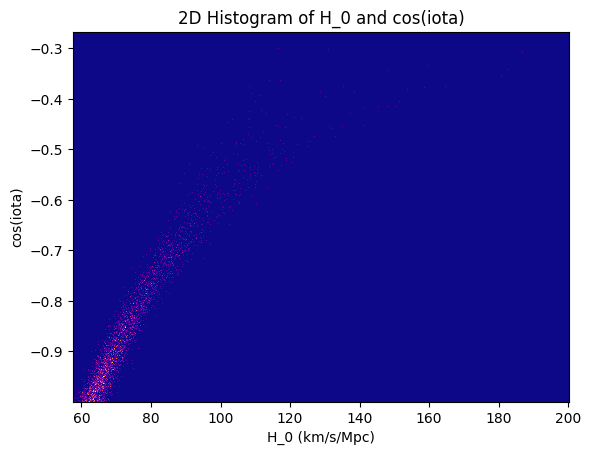

In [60]:
# low redshift approximation: d_L = (c/H_0) * z
H_0 = (c * z) / distances

#Visualize the 2D distribution of H_0 and cos(iota)
plt.hist2d(H_0, cos_iota, bins=500, cmap = 'plasma', range=None, density=False, weights=None, cmin=None, cmax=None, data=None)
plt.xlabel('H_0 (km/s/Mpc)')
plt.ylabel('cos(iota)')
plt.title('2D Histogram of H_0 and cos(iota)')
plt.show()

#### Computation of Jacobian:
$J = \frac{\partial d_L}{\partial H_0} = -\frac{cz}{H_0^2}$,

where we have used the low redshift approximation $d_L = \frac{cz}{H_0}$

In [53]:
# meshgrids used for evaluating the kde on a grid of points
# cos iota from -1 to 1, H_0 from min to max of the samples

H_0_grid, cos_iota_grid = np.meshgrid(np.linspace(min(H_0), max(H_0), 100), np.linspace(-1, 1, 100))

# low redshift approximation: d_L = (c/H_0) * z
d_l_grid = (c * z) / H_0_grid

In [54]:
def likelihood (distances=distances, cos_iota=cos_iota, z=z, H_0_grid=H_0_grid, cos_iota_grid=cos_iota_grid):
    """ 
    Compute the likelihood of the data given the model parameters (H_0, cos(iota)) using a kernel density estimate (kde) of the data.
    Makes use of the low redshift approximation to relate the luminosity distance to H_0 and the redshift.
    """ 
    
    data_l_d_cos_iota = np.vstack((distances,cos_iota)) # needed because kde for 2D takes a 2D array of shape (# dims, # data)

    # kde model
    kde = gaussian_kde(data_l_d_cos_iota)

    # apply kde to the grid points
    # we need to ravel (flatten) the grid points and stack them into a 2D array of shape (# dims, # grid points) for the kde
    kde_values = kde(np.vstack([d_l_grid.ravel(), cos_iota_grid.ravel()]))

    # define jacobian for the transformation from (d_L, cos(iota)) to (H_0, cos(iota))
    J = (c * z) / (H_0_grid**2)

    # likelihood, need to reshape the kde values back to the shape of the grid and multiply by the jacobian
    # grid shape needed for 
    likelihood = kde_values.reshape(H_0_grid.shape) * J

    return likelihood


In [55]:
def H_0_posterior(distances = distances, cos_iota=cos_iota, H_0_grid=H_0_grid, cos_iota_grid=cos_iota_grid):
    """ 
    Compute the posterior distribution of H_0.
    """
    
    # posterior = likelihood * prior
    # we assume a flat prior on cos(iota) and a flat-in-log prior on H_0 (proportional to 1/H_0)
    posterior = likelihood(distances, cos_iota) * (1/H_0_grid)

    # marginalize over cos(iota) by integrating the posterior over cos(iota) from -1 to 1
    unnormalised_posterior_H0 = cumulative_trapezoid(posterior, cos_iota_grid[:,0], initial=0, axis=0)
    normalization = cumulative_trapezoid(unnormalised_posterior_H0, H_0_grid[0,:], initial=0)
    posterior_H0 = unnormalised_posterior_H0 / normalization
    
    return posterior_H0

<function __main__.H_0_posterior(distances=0       45.252574
1       45.872286
2       37.419041
3       47.550072
4       46.396693
          ...    
4036    27.509286
4037    44.951726
4038    38.931113
4039    36.055606
4040    43.414598
Name: luminosity_distance_Mpc, Length: 4041, dtype: float64, cos_iota=0      -0.994916
1      -0.986352
2      -0.805300
3      -0.994375
4      -0.972559
          ...   
4036   -0.572411
4037   -0.967601
4038   -0.821259
4039   -0.726254
4040   -0.866576
Name: costheta_jn, Length: 4041, dtype: float64, H_0_grid=array([[ 57.5395126 ,  58.9808041 ,  60.42209559, ..., 197.34478771,
        198.7860792 , 200.2273707 ],
       [ 57.5395126 ,  58.9808041 ,  60.42209559, ..., 197.34478771,
        198.7860792 , 200.2273707 ],
       [ 57.5395126 ,  58.9808041 ,  60.42209559, ..., 197.34478771,
        198.7860792 , 200.2273707 ],
       ...,
       [ 57.5395126 ,  58.9808041 ,  60.42209559, ..., 197.34478771,
        198.7860792 , 200.2273707 ],
       [